<a href="https://colab.research.google.com/github/SurajReddy469/2520030355__ML/blob/main/Project/Personalized_ML_Recommendation_System(EDA_Code).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personalized Machine Learning Based Recommendation System for Intelligent User Preference Prediction

### Machine Learning Project

**Objective:** Develop a personalized recommendation system that analyzes user behavior and preferences using machine learning techniques and recommends movies that a user is most likely to prefer.

**Technologies:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, TF-IDF, Cosine Similarity, Random Forest.

## 1. Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Download the MovieLens Dataset

In [9]:
# Import the ZIP file library
import zipfile

# Location of the uploaded ZIP file
zip_path = "/content/ml-latest-small.zip"

# Extract the dataset
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load the Dataset

In [11]:
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

print('Movies Dataset:')
display(movies.head())

print('\nRatings Dataset:')
display(ratings.head())

Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 4. Explore the Dataset

In [12]:
print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

print('\nNumber of unique users:', ratings['userId'].nunique())
print('Number of unique movies rated:', ratings['movieId'].nunique())

Movies shape: (9742, 3)
Ratings shape: (100836, 4)

Number of unique users: 610
Number of unique movies rated: 9724


In [13]:
print('Missing values in Movies:')
print(movies.isnull().sum())

print('\nMissing values in Ratings:')
print(ratings.isnull().sum())

Missing values in Movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [14]:
print('Rating Statistics:')
display(ratings['rating'].describe())

Rating Statistics:


,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


## 5. Rating Distribution

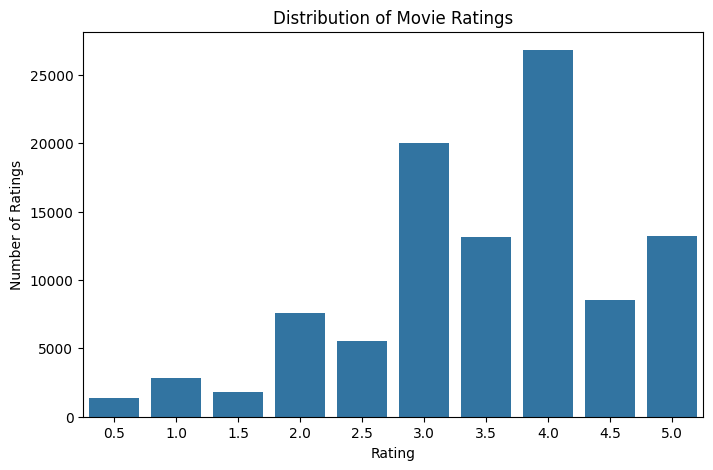

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

## 6. Prepare Movie Features for Content-Based Recommendation

In [16]:
movies['genres'] = movies['genres'].fillna('').str.replace('|', ' ', regex=False)
movies['content'] = movies['title'].fillna('') + ' ' + movies['genres']

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['content'])

print('TF-IDF matrix shape:', tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 9060)


## 7. Calculate Movie Similarity

In [17]:
movie_similarity = cosine_similarity(tfidf_matrix)
print('Movie similarity matrix created successfully!')

Movie similarity matrix created successfully!


## 8. Build the Personalized User Preference Profile

In [18]:
# Merge ratings with movie information
user_movie_data = ratings.merge(movies[['movieId', 'title', 'genres']], on='movieId')

# Convert genres into individual preference scores
genre_rows = []
for _, row in user_movie_data.iterrows():
    for genre in row['genres'].split('|'):
        if genre and genre != '(no genres listed)':
            genre_rows.append([row['userId'], genre, row['rating']])

user_genres = pd.DataFrame(genre_rows, columns=['userId', 'genre', 'rating'])
genre_preferences = user_genres.groupby(['userId', 'genre'])['rating'].mean().reset_index()

print('Sample user genre preferences:')
display(genre_preferences.head(15))

Sample user genre preferences:


,userId,genre,rating
0,1,Action Adventure,5.000000
1,1,Action Adventure Children Comedy Fantasy,4.500000
2,1,Action Adventure Children Fantasy Mystery Thri...,3.000000
3,1,Action Adventure Comedy,5.000000
4,1,Action Adventure Comedy Fantasy,4.000000
5,1,Action Adventure Comedy Fantasy Horror Thriller,2.000000
6,1,Action Adventure Comedy Fantasy Romance,5.000000
7,1,Action Adventure Comedy Romance,4.000000
8,1,Action Adventure Drama,5.000000
9,1,Action Adventure Fantasy,4.600000


## 9. Visualize Preferences of a Sample User

Selected User ID: 414


,userId,genre,rating
29689,414,Action Adventure Animation Children Comedy Fan...,5.0
29749,414,Action Adventure Horror Sci-Fi,5.0
29739,414,Action Adventure Drama Thriller Western,5.0
29966,414,Animation Children Drama Fantasy,5.0
30126,414,Drama Romance War Western,5.0
...,...,...,...
29845,414,Action Fantasy Sci-Fi,1.5
29720,414,Action Adventure Comedy Thriller,1.5
29840,414,Action Drama Thriller Western,1.5
29751,414,Action Adventure Mystery Sci-Fi,1.0


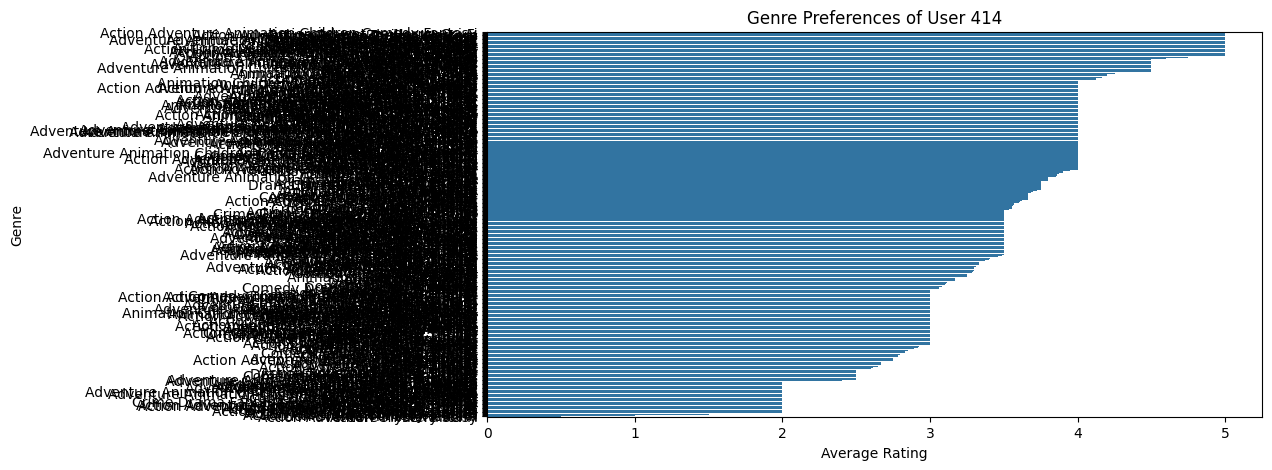

In [19]:
sample_user = int(ratings['userId'].value_counts().index[0])

sample_preferences = genre_preferences[genre_preferences['userId'] == sample_user].sort_values('rating', ascending=False)

print('Selected User ID:', sample_user)
display(sample_preferences)

plt.figure(figsize=(10, 5))
sns.barplot(data=sample_preferences, x='rating', y='genre')
plt.title(f'Genre Preferences of User {sample_user}')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

## 10. Train a Machine Learning Model for Rating Prediction

In [20]:
# Create simple ML features from user/movie interaction history
model_data = ratings.merge(movies[['movieId', 'genres']], on='movieId')
model_data['genre_count'] = model_data['genres'].apply(lambda x: 0 if x == '(no genres listed)' else len(x.split('|')))

# User-level historical features
user_stats = ratings.groupby('userId')['rating'].agg(['mean', 'count']).reset_index()
user_stats.columns = ['userId', 'user_avg_rating', 'user_rating_count']

# Movie-level historical features
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movie_stats.columns = ['movieId', 'movie_avg_rating', 'movie_rating_count']

model_data = model_data.merge(user_stats, on='userId').merge(movie_stats, on='movieId')

features = ['user_avg_rating', 'user_rating_count', 'movie_avg_rating', 'movie_rating_count', 'genre_count']
X = model_data[features]
y = model_data['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print('Machine learning model trained successfully!')

Machine learning model trained successfully!


## 11. Evaluate the Machine Learning Model

In [21]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R² Score: {r2:.4f}')

Mean Absolute Error (MAE): 0.6318
Root Mean Squared Error (RMSE): 0.8424
R² Score: 0.3550


## 12. Generate Personalized Recommendations

In [22]:
def recommend_movies(user_id, n=10):
    """Recommend movies for a user using predicted preference and content similarity."""

    watched = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
    candidates = movies[~movies['movieId'].isin(watched)].copy()

    if candidates.empty:
        return pd.DataFrame()

    # User historical average
    user_ratings = ratings[ratings['userId'] == user_id]
    user_avg = user_ratings['rating'].mean() if len(user_ratings) else ratings['rating'].mean()
    user_count = len(user_ratings)

    # Add movie statistics
    candidates = candidates.merge(movie_stats, on='movieId', how='left')
    candidates['movie_avg_rating'] = candidates['movie_avg_rating'].fillna(ratings['rating'].mean())
    candidates['movie_rating_count'] = candidates['movie_rating_count'].fillna(0)
    candidates['genre_count'] = candidates['genres'].apply(lambda x: 0 if x == '(no genres listed)' else len(x.split('|')))
    candidates['user_avg_rating'] = user_avg
    candidates['user_rating_count'] = user_count

    candidates['predicted_rating'] = model.predict(candidates[features])
    candidates['predicted_rating'] = candidates['predicted_rating'].clip(0.5, 5.0)

    # Blend ML prediction with movie quality/popularity for a robust ranking
    candidates['recommendation_score'] = (
        0.75 * candidates['predicted_rating'] +
        0.25 * candidates['movie_avg_rating']
    )

    return candidates.sort_values('recommendation_score', ascending=False)[
        ['movieId', 'title', 'genres', 'predicted_rating', 'movie_avg_rating', 'recommendation_score']
    ].head(n).reset_index(drop=True)

recommendations = recommend_movies(sample_user, 10)
display(recommendations)

,movieId,title,genres,predicted_rating,movie_avg_rating,recommendation_score
0,47736,"Chump at Oxford, A (1940)",Comedy,4.995,5.0,4.99625
1,149508,Spellbound (2011),Comedy Romance,4.995,5.0,4.99625
2,149566,Unicorn City (2012),Comedy Romance,4.995,5.0,4.99625
3,150554,The Love Bug (1997),Adventure Children Comedy Fantasy,4.995,5.0,4.99625
4,187717,Won't You Be My Neighbor? (2018),Documentary,4.995,5.0,4.99625
5,50999,"Ugly Duckling and Me!, The (2006)",Animation Comedy,4.995,5.0,4.99625
6,156025,Ice Age: The Great Egg-Scapade (2016),Adventure Animation Children Comedy,4.995,5.0,4.99625
7,141928,Bloodsucking Bastards (2015),Comedy Horror,4.995,5.0,4.99625
8,142020,Oscar (1967),Comedy,4.995,5.0,4.99625
9,42556,7 Faces of Dr. Lao (1964),Fantasy Mystery Western,4.995,5.0,4.99625


## 13. Display Top Personalized Recommendations

In [23]:
print(f'Top 10 personalized recommendations for User {sample_user}:\n')
for i, row in recommendations.iterrows():
    print(f"{i+1}. {row['title']} | Predicted Preference: {row['predicted_rating']:.2f}/5 | Score: {row['recommendation_score']:.2f}")

Top 10 personalized recommendations for User 414:

1. Chump at Oxford, A (1940) | Predicted Preference: 5.00/5 | Score: 5.00
2. Spellbound (2011) | Predicted Preference: 5.00/5 | Score: 5.00
3. Unicorn City (2012) | Predicted Preference: 5.00/5 | Score: 5.00
4. The Love Bug (1997) | Predicted Preference: 5.00/5 | Score: 5.00
5. Won't You Be My Neighbor? (2018) | Predicted Preference: 5.00/5 | Score: 5.00
6. Ugly Duckling and Me!, The (2006) | Predicted Preference: 5.00/5 | Score: 5.00
7. Ice Age: The Great Egg-Scapade (2016) | Predicted Preference: 5.00/5 | Score: 5.00
8. Bloodsucking Bastards (2015) | Predicted Preference: 5.00/5 | Score: 5.00
9. Oscar (1967) | Predicted Preference: 5.00/5 | Score: 5.00
10. 7 Faces of Dr. Lao (1964) | Predicted Preference: 5.00/5 | Score: 5.00


## 14. Recommendation Score Visualization

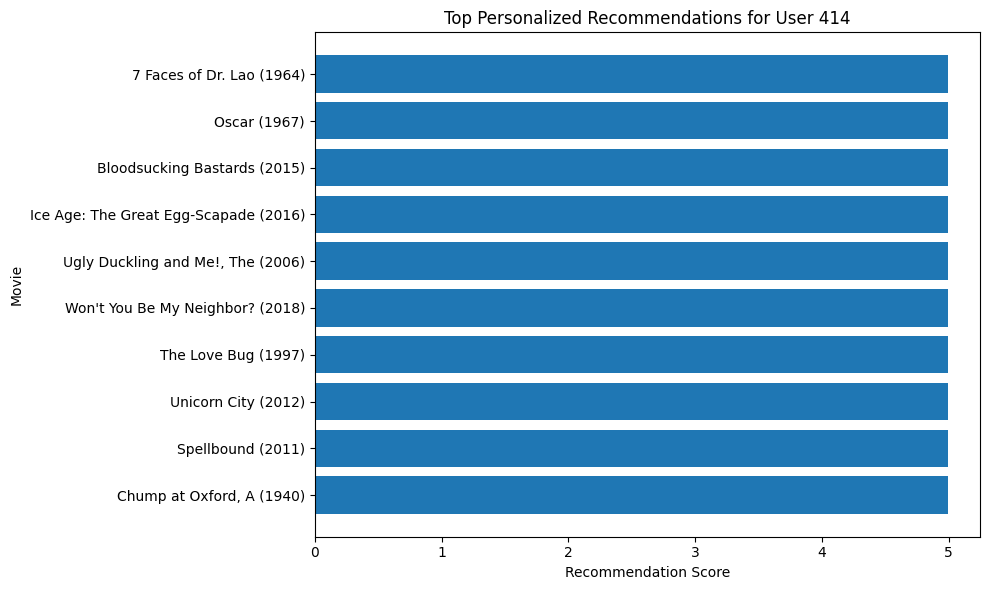

In [24]:
plot_data = recommendations.sort_values('recommendation_score')

plt.figure(figsize=(10, 6))
plt.barh(plot_data['title'], plot_data['recommendation_score'])
plt.title(f'Top Personalized Recommendations for User {sample_user}')
plt.xlabel('Recommendation Score')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

## 15. Test the System with Another User

In [25]:
available_users = sorted(ratings['userId'].unique())
test_user = available_users[min(10, len(available_users)-1)]

print('Testing recommendation system for User ID:', test_user)
display(recommend_movies(test_user, 5))

Testing recommendation system for User ID: 11


,movieId,title,genres,predicted_rating,movie_avg_rating,recommendation_score
0,187717,Won't You Be My Neighbor? (2018),Documentary,5.0,5.0,5.0
1,74226,"Dream of Light (a.k.a. Quince Tree Sun, The) (...",Documentary Drama,5.0,5.0,5.0
2,73822,Meantime (1984),Comedy Drama,5.0,5.0,5.0
3,72692,Mickey's Once Upon a Christmas (1999),Animation Comedy Fantasy,5.0,5.0,5.0
4,72142,Love Exposure (Ai No Mukidashi) (2008),Action Comedy Drama Romance,5.0,5.0,5.0


## 16. Conclusion

The developed system analyzes historical user ratings and movie information to estimate user preferences. A machine learning model predicts expected ratings, while movie features and historical popularity are used to rank unseen movies. The result is a personalized Top-N recommendation list for each user.

### Future Scope
- Add a web interface using Flask or Streamlit.
- Use collaborative filtering or neural recommendation models.
- Include real-time user feedback.
- Add movie posters and external movie metadata.
- Continuously update recommendations as the user interacts with the system.